# Proyecto #2: Maze Solver (v2)

Esta versión sigue la estructura de funciones y el estilo del laboratorio local_search_lab.ipynb, adaptado para los algoritmos de búsqueda informada y no informada solicitados.



EJECUTANDO: Fong_runs/Laberinto1-2.txt
=== CASO BASE ===
Algoritmo            | Longitud   | Nodos      | Tiempo (s)   | B-Factor  
----------------------------------------------------------------------
BFS                  | 652        | 4761       | 0.006005     | 1.0131    


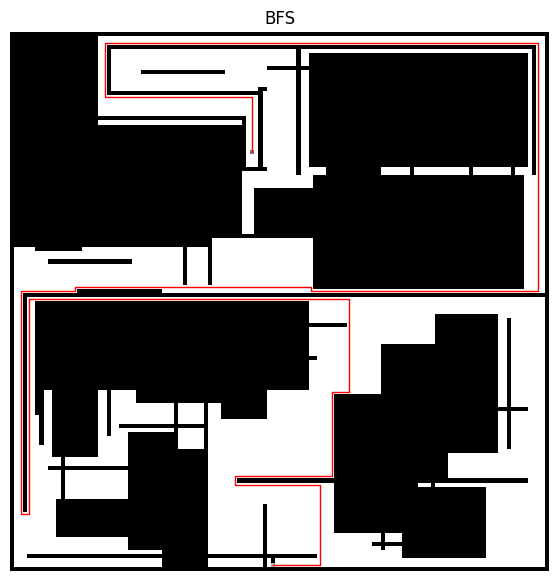

DFS                  | 1860       | 2379       | 0.007001     | 1.0042    


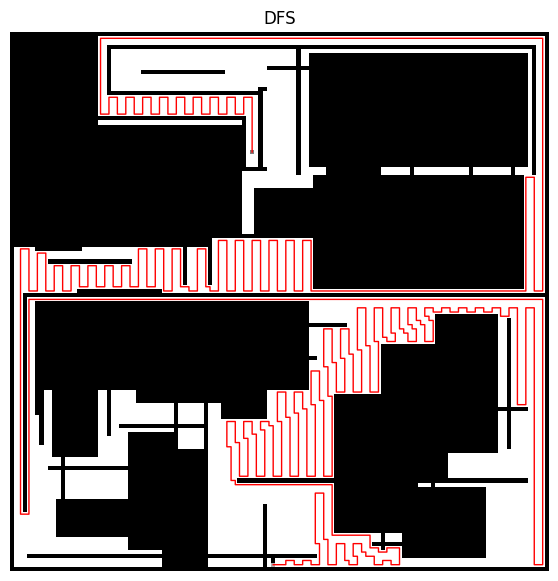

Greedy (Manhattan)   | 662        | 2192       | 0.005998     | 1.0117    


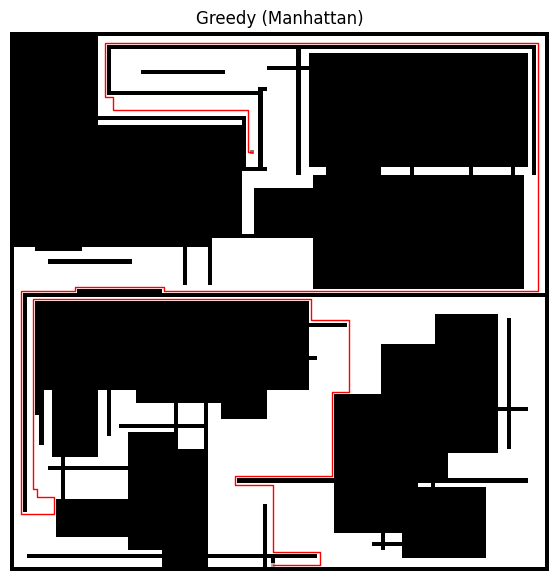

Greedy (Euclidian)   | 686        | 2214       | 0.003981     | 1.0113    


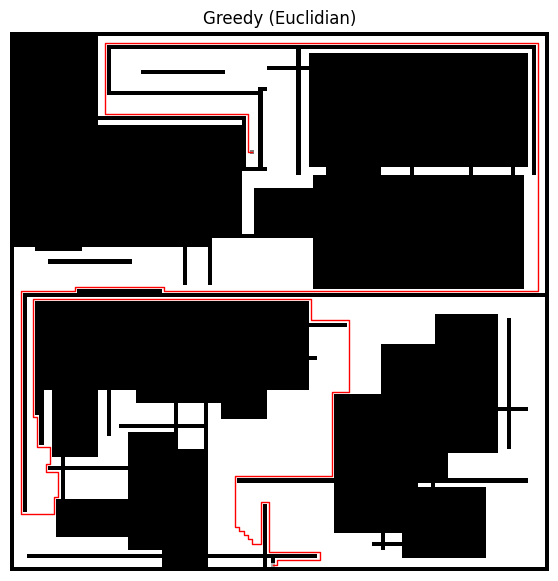

A* (Manhattan)       | 652        | 3709       | 0.011005     | 1.0127    


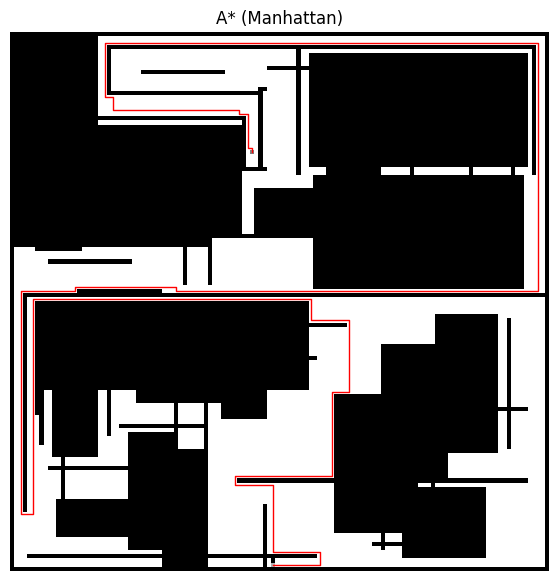

A* (Euclidian)       | 652        | 3849       | 0.009000     | 1.0127    


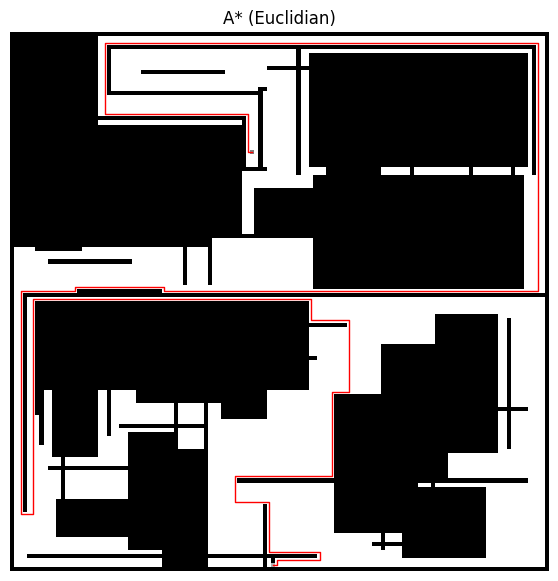


=== SIMULACIÓN ALEATORIA (3 pruebas) ===

-- Prueba 1 | Inicio: (90, 122) | Distancia Manhattan a meta: 96 --
Algoritmo            | Longitud   | Nodos      | Tiempo (s)   | B-Factor  
----------------------------------------------------------------------
BFS                  | 99         | 1709       | 0.000999     | 1.0781    
DFS                  | 371        | 4484       | 0.005004     | 1.0229    
Greedy (Manhattan)   | 99         | 200        | 0.000000     | 1.0550    
Greedy (Euclidian)   | 135        | 238        | 0.001017     | 1.0414    
A* (Manhattan)       | 99         | 240        | 0.000985     | 1.0569    
A* (Euclidian)       | 99         | 678        | 0.000999     | 1.0681    

-- Prueba 2 | Inicio: (67, 119) | Distancia Manhattan a meta: 116 --
Algoritmo            | Longitud   | Nodos      | Tiempo (s)   | B-Factor  
----------------------------------------------------------------------
BFS                  | 125        | 2513       | 0.003018     | 1.0646    
DF

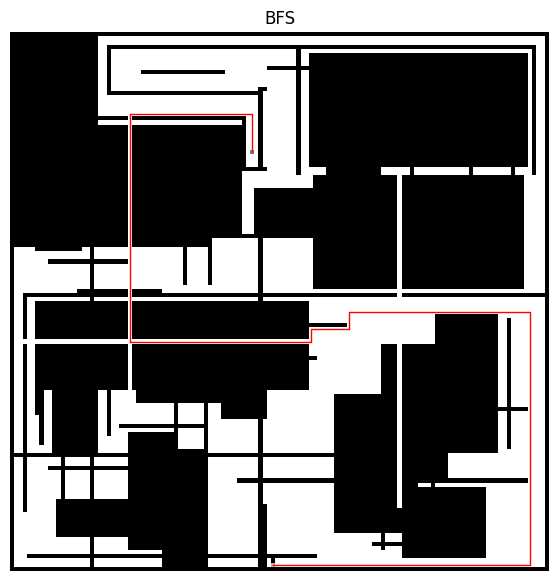

DFS                  | 764        | 3495       | 0.005002     | 1.0107    


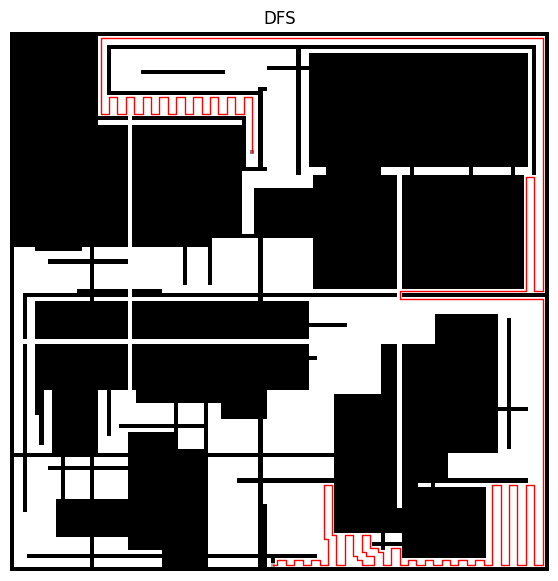

Greedy (Manhattan)   | 342        | 2368       | 0.003983     | 1.0230    


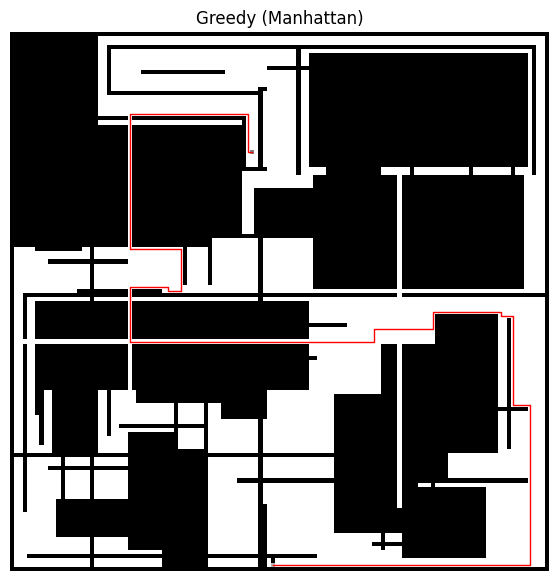

Greedy (Euclidian)   | 406        | 2427       | 0.005984     | 1.0194    


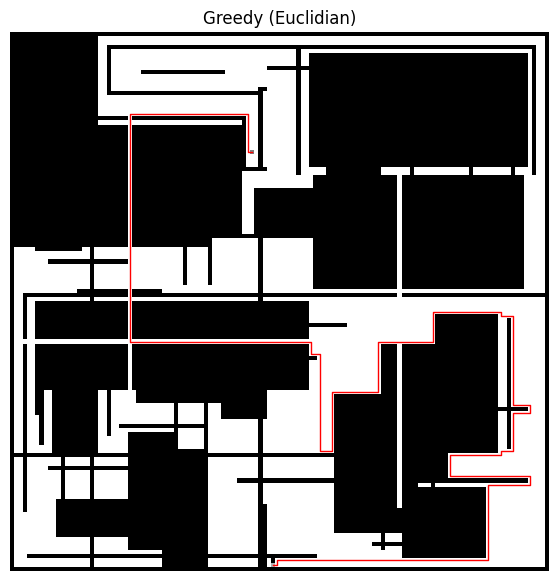

A* (Manhattan)       | 316        | 2921       | 0.008000     | 1.0256    


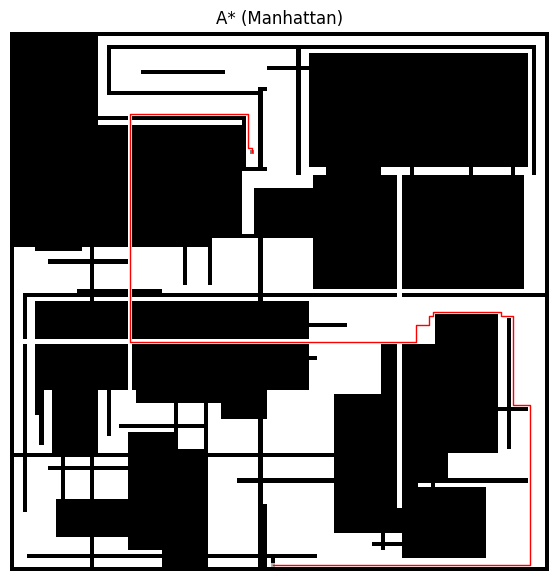

A* (Euclidian)       | 316        | 3768       | 0.009004     | 1.0264    


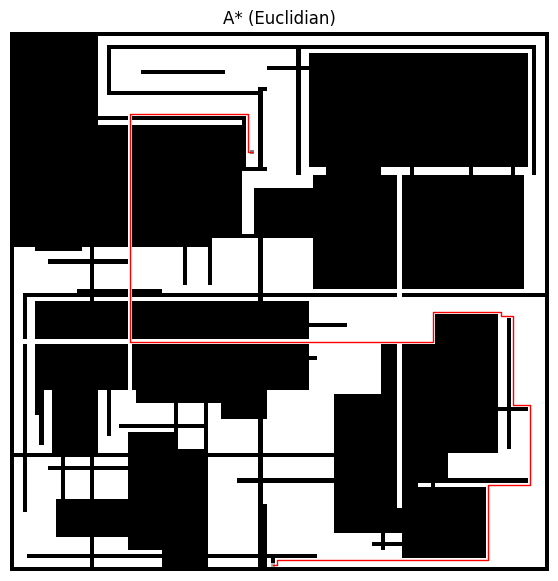


=== SIMULACIÓN ALEATORIA (3 pruebas) ===

-- Prueba 1 | Inicio: (123, 51) | Distancia Manhattan a meta: 14 --
Algoritmo            | Longitud   | Nodos      | Tiempo (s)   | B-Factor  
----------------------------------------------------------------------
BFS                  | No se encontró solución
DFS                  | No se encontró solución
Greedy (Manhattan)   | No se encontró solución
Greedy (Euclidian)   | No se encontró solución
A* (Manhattan)       | No se encontró solución
A* (Euclidian)       | No se encontró solución

-- Prueba 2 | Inicio: (65, 87) | Distancia Manhattan a meta: 86 --
Algoritmo            | Longitud   | Nodos      | Tiempo (s)   | B-Factor  
----------------------------------------------------------------------
BFS                  | 159        | 4022       | 0.004997     | 1.0536    
DFS                  | 969        | 2687       | 0.003003     | 1.0082    
Greedy (Manhattan)   | 173        | 2140       | 0.004015     | 1.0453    
Greedy (Euclidian)   |

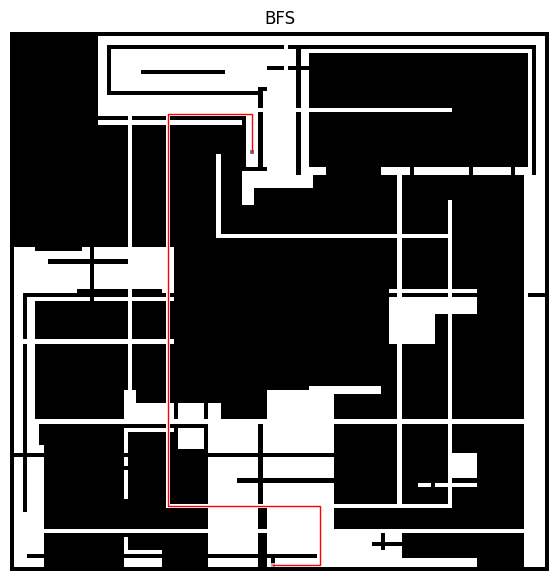

DFS                  | 712        | 3340       | 0.005016     | 1.0115    


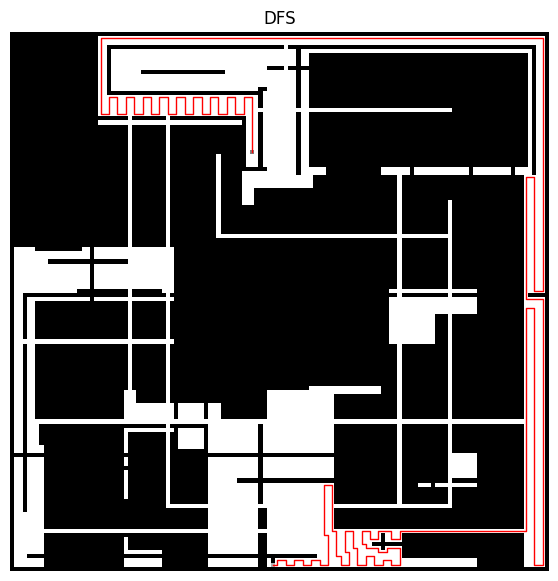

Greedy (Manhattan)   | 188        | 1352       | 0.002994     | 1.0391    


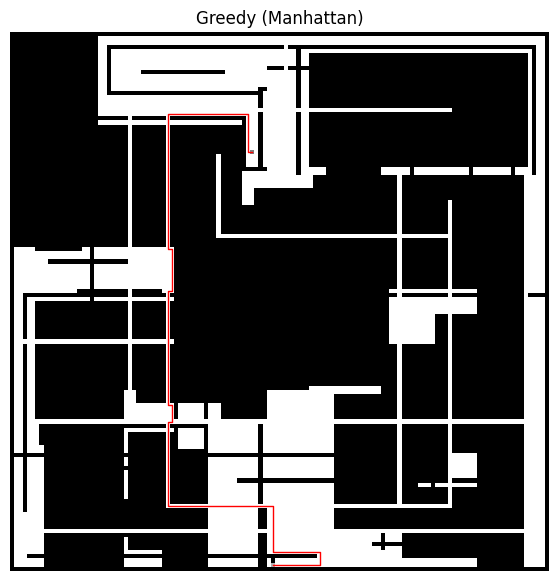

Greedy (Euclidian)   | 188        | 604        | 0.002004     | 1.0346    


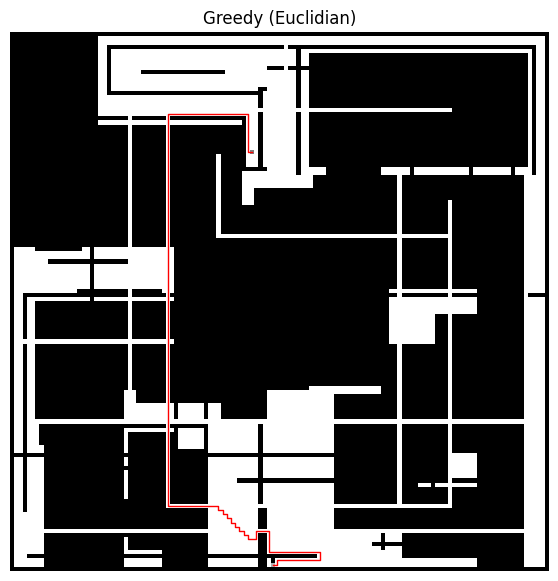

A* (Manhattan)       | 184        | 1964       | 0.006996     | 1.0421    


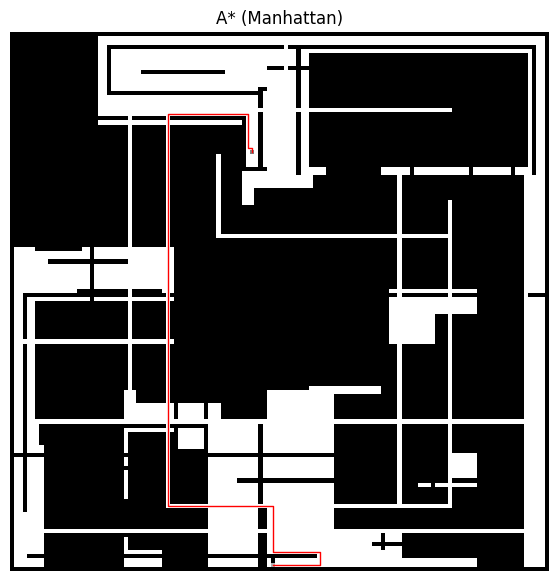

A* (Euclidian)       | 184        | 2468       | 0.005001     | 1.0434    


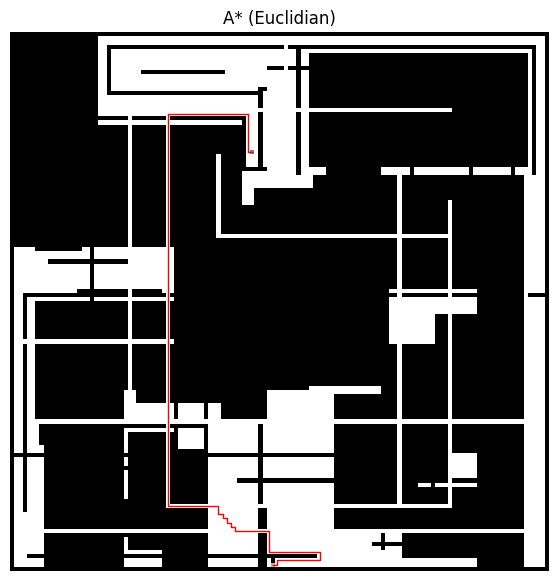


=== SIMULACIÓN ALEATORIA (3 pruebas) ===

-- Prueba 1 | Inicio: (118, 60) | Distancia Manhattan a meta: 10 --
Algoritmo            | Longitud   | Nodos      | Tiempo (s)   | B-Factor  
----------------------------------------------------------------------
BFS                  | 33         | 726        | 0.000999     | 1.2209    
DFS                  | 523        | 4142       | 0.006034     | 1.0161    
Greedy (Manhattan)   | 33         | 132        | 0.000000     | 1.1595    
Greedy (Euclidian)   | 33         | 145        | 0.000986     | 1.1628    
A* (Manhattan)       | 33         | 249        | 0.000000     | 1.1820    
A* (Euclidian)       | 33         | 352        | 0.000983     | 1.1944    

-- Prueba 2 | Inicio: (21, 65) | Distancia Manhattan a meta: 108 --
Algoritmo            | Longitud   | Nodos      | Tiempo (s)   | B-Factor  
----------------------------------------------------------------------
BFS                  | 187        | 3916       | 0.004998     | 1.0452    
DFS

In [2]:
import time
import math
import heapq
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
import os

# --- Estructura de Nodo ---
class Nodo:
    def __init__(self, estado, padre=None, g=0, h=0):
        self.estado = estado
        self.padre = padre
        self.g = g
        self.h = h
        self.f = g + h

    def __lt__(self, otro):
        if self.f == otro.f:
            return self.g > otro.g # Tie-breaker: prefer higher g
        return self.f < otro.f

# --- Funciones Útiles ---

def cargar_laberinto(file_path):
    if not os.path.exists(file_path):
        alt_path = os.path.join('ia_search_project', file_path)
        if os.path.exists(alt_path):
            file_path = alt_path
        elif os.path.exists(os.path.basename(file_path)):
            file_path = os.path.basename(file_path)
        else:
            raise FileNotFoundError(f'No se encontró el archivo: {file_path}')
            
    with open(file_path, 'r') as f:
        grid = [list(line.strip()) for line in f.readlines()]
    return grid

def encontrar_valor(grid, val):
    for r in range(len(grid)):
        for c in range(len(grid[0])):
            if grid[r][c] == val:
                return (r, c)
    return None


def es_meta(estado, meta):
    return estado == meta

def heuristica(estado, meta, tipo='manhattan'):
    if tipo == 'manhattan':
        return abs(estado[0] - meta[0]) + abs(estado[1] - meta[1])
    elif tipo == 'euclidiana':
        return math.sqrt((estado[0] - meta[0])**2 + (estado[1] - meta[1])**2)
    return 0

def generar_sucesores(estado, grid):
    sucesores = []
    rows, cols = len(grid), len(grid[0])
    # Jerarquía: Arriba, Derecha, Abajo, Izquierda
    movimientos = [(-1, 0), (0, 1), (1, 0), (0, -1)]
    
    for dr, dc in movimientos:
        nr, nc = estado[0] + dr, estado[1] + dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] != '1':
            sucesores.append((nr, nc))
    return sucesores

def reconstruir_camino(nodo):
    camino = []
    actual = nodo
    while actual:
        camino.append(actual.estado)
        actual = actual.padre
    return camino[::-1]

def calcular_branching_factor(nodos_explorados, profundidad):
    if profundidad == 0 or nodos_explorados <= 1:
        return 0
    return nodos_explorados ** (1/profundidad)

# --- Algoritmos de Búsqueda ---

def bfs(grid, inicio, meta):
    tiempo_inicio = time.time()
    frontera = deque([Nodo(inicio)])
    visitados = {inicio}
    nodos_explorados = 0
    
    while frontera:
        nodo_actual = frontera.popleft()
        nodos_explorados += 1
        
        if es_meta(nodo_actual.estado, meta):
            return {
                'solucion': True,
                'camino': reconstruir_camino(nodo_actual),
                'nodos': nodos_explorados,
                'tiempo': time.time() - tiempo_inicio
            }
        
        for sucesor in generar_sucesores(nodo_actual.estado, grid):
            if sucesor not in visitados:
                visitados.add(sucesor)
                frontera.append(Nodo(sucesor, nodo_actual))
                
    return {'solucion': False, 'nodos': nodos_explorados, 'tiempo': time.time() - tiempo_inicio}

def dfs(grid, inicio, meta):
    tiempo_inicio = time.time()
    frontera = [Nodo(inicio)]
    visitados = {inicio}
    nodos_explorados = 0
    
    while frontera:
        nodo_actual = frontera.pop()
        nodos_explorados += 1
        
        if es_meta(nodo_actual.estado, meta):
            return {
                'solucion': True,
                'camino': reconstruir_camino(nodo_actual),
                'nodos': nodos_explorados,
                'tiempo': time.time() - tiempo_inicio
            }
        
        sucesores = generar_sucesores(nodo_actual.estado, grid)
        for sucesor in reversed(sucesores):
            if sucesor not in visitados:
                visitados.add(sucesor)
                frontera.append(Nodo(sucesor, nodo_actual))
                
    return {'solucion': False, 'nodos': nodos_explorados, 'tiempo': time.time() - tiempo_inicio}

def greedy(grid, inicio, meta, h_tipo='manhattan'):
    tiempo_inicio = time.time()
    h_inic = heuristica(inicio, meta, h_tipo)
    frontera = [(h_inic, Nodo(inicio, h=h_inic))]
    visitados = {inicio}
    nodos_explorados = 0
    
    while frontera:
        _, nodo_actual = heapq.heappop(frontera)
        nodos_explorados += 1
        
        if es_meta(nodo_actual.estado, meta):
            return {
                'solucion': True,
                'camino': reconstruir_camino(nodo_actual),
                'nodos': nodos_explorados,
                'tiempo': time.time() - tiempo_inicio
            }
        
        for sucesor in generar_sucesores(nodo_actual.estado, grid):
            if sucesor not in visitados:
                visitados.add(sucesor)
                h = heuristica(sucesor, meta, h_tipo)
                heapq.heappush(frontera, (h, Nodo(sucesor, nodo_actual, h=h)))
                
    return {'solucion': False, 'nodos': nodos_explorados, 'tiempo': time.time() - tiempo_inicio}

def a_star(grid, inicio, meta, h_tipo='manhattan'):
    tiempo_inicio = time.time()
    h_inic = heuristica(inicio, meta, h_tipo)
    frontera = [(h_inic, Nodo(inicio, h=h_inic))]
    g_scores = {inicio: 0}
    nodos_explorados = 0
    
    while frontera:
        f_val, nodo_actual = heapq.heappop(frontera)
        if nodo_actual.g > g_scores.get(nodo_actual.estado, float('inf')):
            continue
        nodos_explorados += 1
        
        if es_meta(nodo_actual.estado, meta):
            return {
                'solucion': True,
                'camino': reconstruir_camino(nodo_actual),
                'nodos': nodos_explorados,
                'tiempo': time.time() - tiempo_inicio
            }
        
        for sucesor in generar_sucesores(nodo_actual.estado, grid):
            nuevo_g = nodo_actual.g + 1
            if sucesor not in g_scores or nuevo_g < g_scores[sucesor]:
                g_scores[sucesor] = nuevo_g
                h = heuristica(sucesor, meta, h_tipo)
                nuevo_nodo = Nodo(sucesor, nodo_actual, g=nuevo_g, h=h)
                heapq.heappush(frontera, (nuevo_nodo.f, nuevo_nodo))
                
    return {'solucion': False, 'nodos': nodos_explorados, 'tiempo': time.time() - tiempo_inicio}

def ejecutar_simulacion_aleatoria(archivo_maze, num_pruebas=5):
    grid = cargar_laberinto(archivo_maze)
    meta = encontrar_valor(grid, '3')
    
    # Celdas libres como posibles inicios
    celdas_libres = [(r, c) for r in range(len(grid)) 
                     for c in range(len(grid[0])) 
                     if grid[r][c] == '0']
    
    inicios = random.sample(celdas_libres, min(num_pruebas, len(celdas_libres)))
    
    print(f'\n{"Prueba":<8} | {"Inicio":<15} | {"Longitud":<10} | {"Nodos":<10} | {"Tiempo (s)":<12} | {"B-Factor":<10}')
    print('-' * 75)
    
    for i, inicio in enumerate(inicios):
        res = a_star(grid, inicio, meta, h_tipo='manhattan')
        if res['solucion']:
            length = len(res['camino'])
            bf = calcular_branching_factor(res['nodos'], length)
            print(f'{i+1:<8} | {str(inicio):<15} | {length:<10} | {res["nodos"]:<10} | {res["tiempo"]:<12.6f} | {bf:<10.4f}')
        else:
            print(f'{i+1:<8} | {str(inicio):<15} | Sin solución')

# --- Visualización y Experimentos ---

def visualizar_laberinto(grid, camino=None, titulo='Laberinto'):
    rows, cols = len(grid), len(grid[0])
    data = np.zeros((rows, cols))
    for r in range(rows):
        for c in range(cols):
            if grid[r][c] == '0': data[r, c] = 1 
            elif grid[r][c] == '2': data[r, c] = 0.5
            elif grid[r][c] == '3': data[r, c] = 0.7
            else: data[r, c] = 0  
    
    plt.figure(figsize=(7, 7))
    plt.imshow(data, cmap='gray')
    if camino:
        rs, cs = zip(*camino)
        plt.plot(cs, rs, color='red', linewidth=1)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

def ejecutar_comparativa(archivo_maze, num_pruebas_aleatorias=3):
    grid = cargar_laberinto(archivo_maze)
    inicio = encontrar_valor(grid, '2')
    meta = encontrar_valor(grid, '3')
    
    algos = [
        ('BFS', bfs, {}),
        ('DFS', dfs, {}),
        ('Greedy (Manhattan)', greedy, {'h_tipo': 'manhattan'}),
        ('Greedy (Euclidian)', greedy, {'h_tipo': 'euclidiana'}),
        ('A* (Manhattan)', a_star, {'h_tipo': 'manhattan'}),
        ('A* (Euclidian)', a_star, {'h_tipo': 'euclidiana'})
    ]

    # --- Caso Base ---
    print('=== CASO BASE ===')
    print(f'{"Algoritmo":<20} | {"Longitud":<10} | {"Nodos":<10} | {"Tiempo (s)":<12} | {"B-Factor":<10}')
    print('-' * 70)

    for nombre, func, kwargs in algos:
        res = func(grid, inicio, meta, **kwargs)
        if res['solucion']:
            length = len(res['camino'])
            bf = calcular_branching_factor(res['nodos'], length)
            print(f'{nombre:<20} | {length:<10} | {res["nodos"]:<10} | {res["tiempo"]:<12.6f} | {bf:<10.4f}')
            visualizar_laberinto(grid, res['camino'], titulo=nombre)
        else:
            print(f'{nombre:<20} | No se encontró solución')

    # --- Puntos de Partida Aleatorios ---
    print(f'\n=== SIMULACIÓN ALEATORIA ({num_pruebas_aleatorias} pruebas) ===')
    
    celdas_libres = [(r, c) for r in range(len(grid))
                     for c in range(len(grid[0]))
                     if grid[r][c] == '0']
    
    inicios_aleatorios = random.sample(celdas_libres, min(num_pruebas_aleatorias, len(celdas_libres)))
    
    # Ordenar por distancia manhattan para ver tendencia por distancia
    inicios_aleatorios.sort(key=lambda p: heuristica(p, meta, 'manhattan'))

    for i, inicio_aleatorio in enumerate(inicios_aleatorios):
        distancia = heuristica(inicio_aleatorio, meta, 'manhattan')
        print(f'\n-- Prueba {i+1} | Inicio: {inicio_aleatorio} | Distancia Manhattan a meta: {distancia} --')
        print(f'{"Algoritmo":<20} | {"Longitud":<10} | {"Nodos":<10} | {"Tiempo (s)":<12} | {"B-Factor":<10}')
        print('-' * 70)
        
        for nombre, func, kwargs in algos:
            res = func(grid, inicio_aleatorio, meta, **kwargs)
            if res['solucion']:
                length = len(res['camino'])
                bf = calcular_branching_factor(res['nodos'], length)
                print(f'{nombre:<20} | {length:<10} | {res["nodos"]:<10} | {res["tiempo"]:<12.6f} | {bf:<10.4f}')
            else:
                print(f'{nombre:<20} | No se encontró solución')

# Ejecutar laberintos del directorio Fong_runs
laberintos_fong = [
    "Fong_runs/Laberinto1-2.txt",
    "Fong_runs/Laberinto2-2.txt",
    "Fong_runs/Laberinto3-2.txt"
]

for archivo in laberintos_fong:
    print(f'\n\n{"="*80}')
    print(f'EJECUTANDO: {archivo}')
    print(f'{"="*80}')
    ejecutar_comparativa(archivo, num_pruebas_aleatorias=3)
